In [1]:
import rasterio
import subprocess
import geo_utils
import os

In [2]:
data_dir = '../data'

# 1. process global map 2019 data
1a. crop the huge CHM prediction file to the extent of the merged S2 imagery so it's easier to work with later


In [3]:
# TODO (Esther) fix this
lidar_dir = os.path.join(data_dir, 'raw/lidar_by_site_32736')
input_lidar_sites = [os.path.join(lidar_dir, x) for x in os.listdir(lidar_dir) if x.endswith('.tif')]
tmp_file = '/tmp/all_lidar_tif.tif'
geo_utils.merge_tifs(input_lidar_sites, tmp_file, output_type='Float32')

0...10...20...30...40...50...60...70...80...90...100 - done.


1b. align the 2019 predictions to the lidar 10m. 

In [ ]:
from importlib import reload
reload(geo_utils)

fp_2019_in = os.path.join(data_dir, 'raw/global_tch_maps/Forest_height_2019_SAFR.tif')
fp_2019_cropped = os.path.join(data_dir, 'raw/global_tch_maps/Forest_height_2019_SAFR_cropped.tif')
geo_utils.crop_input_to_target_tif(fp_2019_in, 
                                   fp_2019_cropped, 
                                   target_fn = tmp_file, 
                                   output_type='Byte', # same as input
                                   pixel_buffer=40,
                                   output_nodata='255')

In [5]:
# You can now safely delete these files to make room
os.remove(tmp_file)
os.remove(fp_2019_in)

# 2. process ETH data
2a. combine the two ETH data files into one so it's easier to work with later

In [8]:
# 2a. combine the two ETH data files into one
input_fns = [
    data_dir + '/raw/global_tch_maps/eth/ETH_GlobalCanopyHeight_10m_2020_S24E030_Map.tif',
    data_dir + '/raw/global_tch_maps/eth/ETH_GlobalCanopyHeight_10m_2020_S27E030_Map.tif',
]
tch_out_dir = os.path.join(data_dir,'int/global_tch_maps/')
if not os.path.exists(tch_out_dir): os.mkdir(tch_out_dir)
merged_eth_fn = os.path.join(tch_out_dir, 'ETH_GlobalCanopyHeight_10m_merged.tif')

geo_utils.merge_tifs(input_fns, merged_eth_fn, output_type='Byte'), # same as input

0...10...20...30...40...50...60...70...80...90...100 - done.


(None,)

In [9]:
merged_eth_fn = os.path.join(tch_out_dir, 'ETH_GlobalCanopyHeight_10m_merged.tif')

2b. make a per-site file of each.

In [10]:
# make a per-site file of each to match the 10m resolution data
compare_map_dir = os.path.join(data_dir,'existing_reference_data')
if not os.path.exists(compare_map_dir): os.mkdir(compare_map_dir)
compare_eth_dir = os.path.join(compare_map_dir,'eth_maps_per_site_10m')
if not os.path.exists(compare_eth_dir): os.mkdir(compare_eth_dir)

In [11]:
label_dir = os.path.join(data_dir, 'int/lidar/lidar_by_site_32736_10m')
site_names = os.listdir(label_dir)
len(site_names)

24

In [14]:
reload(geo_utils)
for site_name in site_names:
    # find the label file
    tif_fns = os.listdir(os.path.join(label_dir, site_name))
    assert len(tif_fns) == 1
    tif_fn = tif_fns[0]
    target_fn = os.path.join(label_dir, site_name, tif_fn)

    output_fn = os.path.join(compare_eth_dir, f'ETH_MAP_{site_name}_10m.tif')
    
    geo_utils.match_input_to_target_tif(input_fn=merged_eth_fn, 
                              output_fn=output_fn, 
                              target_fn=target_fn, 
                              pixel_buffer = 0, 
                              verbose=False, 
                              output_type='Float32',
                              resampling="average",
                              src_nodata='255',
                              output_nodata='-9999.')

Creating output file that is 479P x 486L.
Processing ../data/int/global_tch_maps/ETH_GlobalCanopyHeight_10m_merged.tif [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.
Creating output file that is 474P x 484L.
Processing ../data/int/global_tch_maps/ETH_GlobalCanopyHeight_10m_merged.tif [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.
Creating output file that is 475P x 486L.
Processing ../data/int/global_tch_maps/ETH_GlobalCanopyHeight_10m_merged.tif [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.
Creating output file that is 479P x 491L.
Processing ../data/int/global_tch_maps/ETH_GlobalCanopyHeight_10m_merged.tif [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.
Creating output file that is 558P x 390L.
Processing ../data/int/global_tch_maps/ETH_GlobalCanopyHeight_10m_merged.tif [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.
Creating output file that is 481P x 475L.
Processing ../data

In [ ]:
import matplotlib.pyplot as plt

In [18]:
with rasterio.open(output_fn) as f:
    data = f.read()
    


(array([9.9955e+04, 1.2492e+04, 9.7080e+03, 7.8940e+03, 5.5790e+03,
        5.4860e+03, 1.8050e+03, 5.4200e+02, 3.7900e+02, 9.8000e+01]),
 array([ 0.        ,  1.79999995,  3.5999999 ,  5.4000001 ,  7.19999981,
         9.        , 10.80000019, 12.60000038, 14.39999962, 16.20000076,
        18.        ]),
 <BarContainer object of 10 artists>)

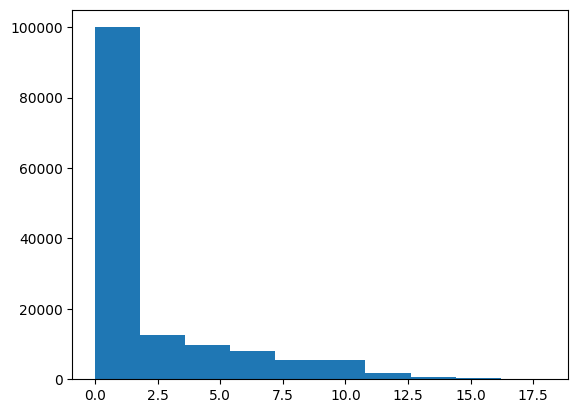

In [21]:
plt.hist(data[data != -9999.].ravel())